In [3]:
import numpy as np
from scipy.integrate import quad, simps
from scipy.interpolate import interp1d
import time
import matplotlib.pyplot as plt

In [4]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [5]:
# Schechter function parameters
L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e9
L_MAX_SCH = 1e16 

In [6]:
L_grid = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 10000)
phi_grid = schechter_function(L_grid, L_STAR, ALPHA_SCH)

from scipy.integrate import cumtrapz
cdf_grid = cumtrapz(phi_grid, L_grid, initial=0)
cdf_grid = cdf_grid / cdf_grid[-1]

# Create interpolator ONCE
from scipy.interpolate import interp1d
schechter_inverse_cdf = interp1d(cdf_grid, L_grid, kind='linear', 
                                    bounds_error=False, fill_value=(L_MIN_SCH, L_MAX_SCH))


/tmp/ipykernel_3575787/4098017378.py:5: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf_grid = cumtrapz(phi_grid, L_grid, initial=0)


In [7]:
def schechter_luminosity(L_star, alpha, L_min, L_max, size=1):
    """
    Generate luminosities following the Schechter function using inverse transform sampling.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Uses numerical integration and interpolation for accurate sampling.
    """
    """Fast version using pre-computed inverse CDF"""
    u = np.random.uniform(0, 1, size=size)
    L_samples = schechter_inverse_cdf(u)
    return L_samples[0] if size == 1 else L_samples

Generating 1,000,000,000 luminosity values. This may take a moment...



--- Generation Complete ---
Successfully generated 1,000,000,000 luminosity values.
Time taken: 295.5263 seconds
Shape of the array: (1000000000,)
Memory usage: 8.00 GB

Plotting a histogram of a 1,000,000-point sample...


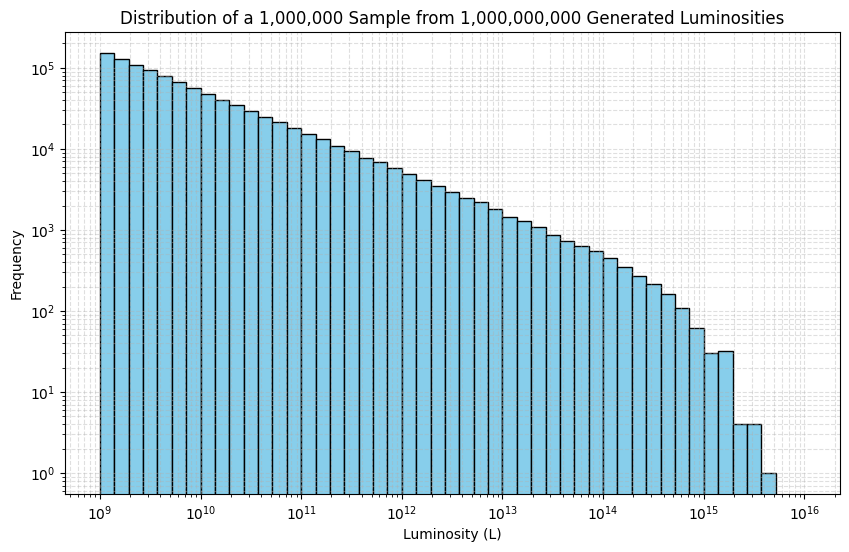

In [8]:

num_samples = 1_000_000_000
print(f"Generating {num_samples:,} luminosity values. This may take a moment...")

# Record the start time
start_time = time.time()

# Generate the random luminosities
luminosities = schechter_luminosity(L_STAR, ALPHA_SCH, L_MIN_SCH, L_MAX_SCH, size=num_samples)

# Record the end time
end_time = time.time()

# Calculate and print the elapsed time
elapsed_time = end_time - start_time

print("\n--- Generation Complete ---")
print(f"Successfully generated {len(luminosities):,} luminosity values.")
print(f"Time taken: {elapsed_time:.4f} seconds")
print(f"Shape of the array: {luminosities.shape}")
print(f"Memory usage: {luminosities.nbytes / 1e9:.2f} GB")


# --- Plot a histogram of a SAMPLE of the data to visualize the distribution ---
# Plotting all 1 billion points is not feasible, so we take a random sample.
print("\nPlotting a histogram of a 1,000,000-point sample...")
sample_size = 1_000_000
plot_sample = np.random.choice(luminosities, size=sample_size, replace=False)

plt.figure(figsize=(10, 6))
plt.hist(plot_sample, bins=np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 50), color='skyblue', edgecolor='black')
plt.xscale('log')
plt.yscale('log')
plt.title(f'Distribution of a {sample_size:,} Sample from {num_samples:,} Generated Luminosities')
plt.xlabel('Luminosity (L)')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="--", alpha=0.4)


In [9]:
print(f"Max L: {np.max(luminosities):.3e}")

Max L: 8.952e+15


In [10]:
np.save('SF_luminosities.npy', luminosities)


In [11]:
L = np.load('SF_luminosities.npy')